In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
raw_path = "../../data/raw/"
df=pd.read_csv(raw_path + 'raw_longest.csv')
df

,time,result,table,controller,site,digital_input_1_and_2,power_factor_avg,power_factor_l1,power_factor_l2,power_factor_l3,...,power_l1,power_l2,power_l3,power_total,energy_export,energy_import,reactive_power_l1,reactive_power_l2,reactive_power_l3,reactive_power_total
0,2025-11-05 06:00:00+00:00,0.0,5.430769,0.0,0.0,0.0,0.79,0.872000,0.800000,0.710000,...,0.135066,0.100593,0.116841,0.352846,182.8,37.700000,0.075044,0.076632,0.116576,0.268209
1,2025-11-05 06:15:00+00:00,0.0,5.442105,0.0,0.0,0.0,0.79,0.871429,0.792857,0.705714,...,0.136399,0.101432,0.117955,0.355975,182.8,37.885714,0.076372,0.077894,0.118380,0.272378
2,2025-11-05 06:30:00+00:00,0.0,5.231579,0.0,0.0,0.0,0.79,0.870000,0.790000,0.702857,...,0.136216,0.101376,0.118240,0.356162,182.8,38.000000,0.076818,0.078288,0.119212,0.274299
3,2025-11-05 06:45:00+00:00,0.0,5.273585,0.0,0.0,0.0,0.79,0.870000,0.790000,0.702500,...,0.136388,0.101520,0.118302,0.355818,182.8,38.000000,0.076791,0.078409,0.119299,0.274591
4,2025-11-05 07:00:00+00:00,0.0,5.490000,0.0,0.0,0.0,0.79,0.870000,0.790000,0.700000,...,0.136882,0.101749,0.118393,0.357117,182.8,38.075000,0.077008,0.078690,0.119680,0.275467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9475,2026-02-11 22:45:00+00:00,0.0,5.450980,0.0,0.0,0.0,0.73,0.760000,0.710000,0.740000,...,1.058030,0.932165,1.845840,3.838310,182.8,8623.000000,0.917849,0.935142,1.699960,3.552420
9476,2026-02-11 23:00:00+00:00,0.0,5.000000,0.0,0.0,0.0,0.73,0.760000,0.702500,0.740000,...,1.059732,0.927292,1.843703,3.831455,182.8,8623.750000,0.919044,0.932784,1.699975,3.553883
9477,2026-02-11 23:15:00+00:00,0.0,5.405405,0.0,0.0,0.0,0.73,0.760000,0.700000,0.740000,...,1.063250,0.933172,1.842850,3.836670,182.8,8624.400000,0.918017,0.937175,1.702390,3.560180
9478,2026-02-11 23:30:00+00:00,0.0,5.320755,0.0,0.0,0.0,0.78,0.850000,0.710000,0.740000,...,1.993200,0.925165,1.815090,4.734360,182.8,8670.000000,1.224630,0.924850,1.655290,3.806280


In [4]:
df.columns

Index(['time', 'result', 'table', 'controller', 'site',
       'digital_input_1_and_2', 'power_factor_avg', 'power_factor_l1',
       'power_factor_l2', 'power_factor_l3', 'units', 'current_l1_thd',
       'current_l3_thd', 'current_unbalance', 'volts_l1_thd', 'volts_l2_thd',
       'volts_l3_thd', 'volts_unbalance', 'current_avg', 'current_l1',
       'current_l2', 'current_l3', 'freq', 'volts_l1_l2', 'volts_l1_n',
       'volts_l2_l3', 'volts_l2_n', 'volts_l3_l1', 'volts_l3_n',
       'volts_l_l_avg', 'volts_l_n_avg', 'apparent_power_demand',
       'apparent_power_l1', 'apparent_power_l2', 'apparent_power_l3',
       'apparent_power_total', 'apparent_energy', 'reactive_power_demand',
       'reactive_energy_export', 'reactive_energy_import', 'max_power_demand',
       'power_demand', 'power_l1', 'power_l2', 'power_l3', 'power_total',
       'energy_export', 'energy_import', 'reactive_power_l1',
       'reactive_power_l2', 'reactive_power_l3', 'reactive_power_total'],
      dtype='ob

In [5]:
# ---- Clean & standardize time ----
df['time'] = pd.to_datetime(df['time'])

In [6]:
# Sort by time (very important in industry)
df = df.sort_values('time').reset_index(drop=True)


In [7]:
print("Raw extracted shape:", df.shape)
print(df.head())

Raw extracted shape: (9480, 52)
                       time  result     table  controller  site  \
0 2025-11-05 06:00:00+00:00     0.0  5.430769         0.0   0.0   
1 2025-11-05 06:15:00+00:00     0.0  5.442105         0.0   0.0   
2 2025-11-05 06:30:00+00:00     0.0  5.231579         0.0   0.0   
3 2025-11-05 06:45:00+00:00     0.0  5.273585         0.0   0.0   
4 2025-11-05 07:00:00+00:00     0.0  5.490000         0.0   0.0   

   digital_input_1_and_2  power_factor_avg  power_factor_l1  power_factor_l2  \
0                    0.0              0.79         0.872000         0.800000   
1                    0.0              0.79         0.871429         0.792857   
2                    0.0              0.79         0.870000         0.790000   
3                    0.0              0.79         0.870000         0.790000   
4                    0.0              0.79         0.870000         0.790000   

   power_factor_l3  ...  power_l1  power_l2  power_l3  power_total  \
0         0.71

In [8]:
# Keep time + only numeric sensor columns
df_raw = df.copy()
df_ahu = df_raw.select_dtypes(include=['float64', 'int64'])
df_ahu.insert(0, 'time', df_raw['time'])

print("Raw AHU dataframe shape:", df_ahu.shape)
print(df_ahu.head())

Raw AHU dataframe shape: (9480, 52)
                       time  result     table  controller  site  \
0 2025-11-05 06:00:00+00:00     0.0  5.430769         0.0   0.0   
1 2025-11-05 06:15:00+00:00     0.0  5.442105         0.0   0.0   
2 2025-11-05 06:30:00+00:00     0.0  5.231579         0.0   0.0   
3 2025-11-05 06:45:00+00:00     0.0  5.273585         0.0   0.0   
4 2025-11-05 07:00:00+00:00     0.0  5.490000         0.0   0.0   

   digital_input_1_and_2  power_factor_avg  power_factor_l1  power_factor_l2  \
0                    0.0              0.79         0.872000         0.800000   
1                    0.0              0.79         0.871429         0.792857   
2                    0.0              0.79         0.870000         0.790000   
3                    0.0              0.79         0.870000         0.790000   
4                    0.0              0.79         0.870000         0.790000   

   power_factor_l3  ...  power_l1  power_l2  power_l3  power_total  \
0         

15 min resampling 

In [9]:
df_ahu = df_ahu.set_index('time')

In [10]:
#now resample
df_resampled = df_ahu.resample('15T').mean()


In [11]:
print("Resampled shape:", df_resampled.shape)
print(df_resampled.head(10))


Resampled shape: (9480, 51)
                           result     table  controller  site  \
time                                                            
2025-11-05 06:00:00+00:00     0.0  5.430769         0.0   0.0   
2025-11-05 06:15:00+00:00     0.0  5.442105         0.0   0.0   
2025-11-05 06:30:00+00:00     0.0  5.231579         0.0   0.0   
2025-11-05 06:45:00+00:00     0.0  5.273585         0.0   0.0   
2025-11-05 07:00:00+00:00     0.0  5.490000         0.0   0.0   
2025-11-05 07:15:00+00:00     0.0  5.178571         0.0   0.0   
2025-11-05 07:30:00+00:00     0.0  5.473118         0.0   0.0   
2025-11-05 07:45:00+00:00     0.0  5.250000         0.0   0.0   
2025-11-05 08:00:00+00:00     0.0  5.568627         0.0   0.0   
2025-11-05 08:15:00+00:00     0.0  5.336957         0.0   0.0   

                           digital_input_1_and_2  power_factor_avg  \
time                                                                 
2025-11-05 06:00:00+00:00                    0.0   

In [12]:
missing_counts = df_resampled.isna().sum()
print("Missing values per column:\n")
print(missing_counts[missing_counts > 0])


Missing values per column:

Series([], dtype: int64)


In [13]:
#to check time gap
print("\nTime gaps:")
print(df_resampled.index.to_series().diff().value_counts())



Time gaps:
time
0 days 00:15:00    9479
Name: count, dtype: int64


<Axes: xlabel='time'>

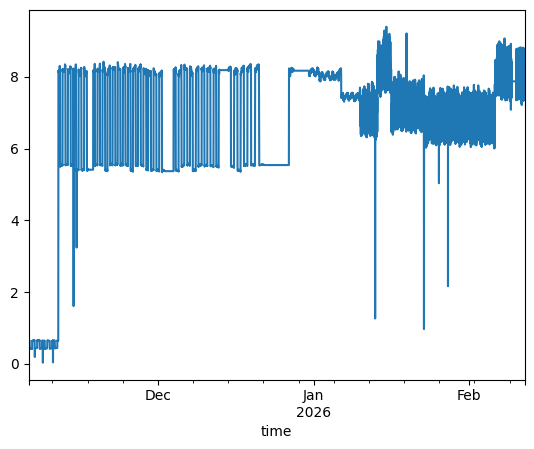

In [14]:
#is the machine drawing more current over time ?
df_resampled['current_avg'].plot()
